In [86]:
from os import path


import numpy as np
import pandas as pd
from scipy import signal, interpolate
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr
from scipy.optimize import curve_fit, minimize
import plotly.graph_objects as go

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import folium


Input definitions

In [91]:
# source_path = r"C:\Users\joses\Mi unidad\TRABAJO\49_profile_estimation\TRABAJO\spectrogram_based\datasets\metrotranvia\experimental"
# dataset = '1'
# subtract_g = 0
# t_ini, t_fin = 50, 1535 # s
# tmax = 1540
# tlim = (-150, tmax)
# v_th_mask = 8.0 # 8.0 # m/s
# inter_sleepers = 0.60  # m, measured with google earth 0.65
# wheel_base = 1.80  # m, taken from https://www.trainweb.us/ctrain/u2actech.html#:~:text=Technical%20Information%20Siemens%20U2%20AC,Rating%20per%20Motor
# inter_bogie = 9  # m, (35.09/7.04)*wheel_base,  # m, measured relatively from https://en.wikipedia.org/wiki/Siemens%E2%80%93Duewag_U2
# win_len = 100 # Good values [50, 100] for metrotranvia


# source_path = r"C:\Users\joses\Mi unidad\TRABAJO\49_profile_estimation\TRABAJO\spectrogram_based\datasets\metrotranvia\simulations"
# dataset = '2'
# subtract_g = 0
# t_ini, t_fin = 0.0, 6.0 # s
# tmax = 6.5
# tlim = (-.5, tmax)
# v_th_mask = 6.0 # m/s
# inter_sleepers = 0.5  # m, input parameter of simulations
# wheel_base = np.nan  # m, taken from https://www.trainweb.us/ctrain/u2actech.html#:~:text=Technical%20Information%20Siemens%20U2%20AC,Rating%20per%20Motor
# inter_bogie = np.nan  # m, (35.09/7.04)*wheel_base,  # m, measured relatively from https://en.wikipedia.org/wiki/Siemens%E2%80%93Duewag_U2
# win_len = 25 # Good values [25, 50] for metrotranvia

source_path = r"D:\CONICET\tren_marcuzzi"
dataset = ''
subtract_g = 1.0
t_ini, t_fin = 500.0, 4800.0 # s
tmax = 5000.0
tlim = (-.5, tmax)
v_th_mask = 2.0 # m/s
inter_sleepers = 0.57 # m, to check
wheel_base = 1.73  # m, checked
inter_bogie = 4.0  # m, checked
win_len = 100 # Good values [100] for tren


flim = (0, 50)  # Hz

Data extraction

In [88]:
def load_dataset_n(source_path: str, path_n: str, t_ini: float, t_fin: float, n_dataset: int = 0, subtract_g: float = 0):
    loc_orig_df_n = pd.read_csv(path.join(source_path, path_n, "Location.csv"))
    acc_orig_df_n = pd.read_csv(path.join(source_path, path_n, "Accelerometer.csv"))

    t_ini_loc, t_fin_loc = loc_orig_df_n['seconds_elapsed'][0], loc_orig_df_n['seconds_elapsed'].iloc[-1]
    t_ini_acc, t_fin_acc = acc_orig_df_n['seconds_elapsed'][0], acc_orig_df_n['seconds_elapsed'].iloc[-1]
    print(f"{t_ini_acc=}, {t_fin_acc=}; {t_ini_loc=}, {t_fin_loc=}")

    loc_orig_df_n = loc_orig_df_n.loc[loc_orig_df_n['seconds_elapsed'] >= t_ini].loc[loc_orig_df_n['seconds_elapsed'] <= t_fin].reset_index()
    acc_orig_df_n = acc_orig_df_n.loc[acc_orig_df_n['seconds_elapsed'] >= t_ini].loc[acc_orig_df_n['seconds_elapsed'] <= t_fin].reset_index()
    
    t_ini_loc, t_fin_loc = loc_orig_df_n['seconds_elapsed'][0], loc_orig_df_n['seconds_elapsed'].iloc[-1]
    t_ini_acc, t_fin_acc = acc_orig_df_n['seconds_elapsed'][0], acc_orig_df_n['seconds_elapsed'].iloc[-1]
    print(f"{t_ini_acc=}, {t_fin_acc=}; {t_ini_loc=}, {t_fin_loc=}")

    acc_orig_df_n['z'] = acc_orig_df_n['z'] + subtract_g*9.81

    map = folium.Map(location=[loc_orig_df_n['latitude'].iloc[0], loc_orig_df_n['longitude'].iloc[0]], zoom_start=14)
    folium.PolyLine(list(zip(loc_orig_df_n['latitude'], loc_orig_df_n['longitude'])), color="blue", weight=2.5, opacity=1, popup=f'dataset_{n_dataset}').add_to(map)

    return loc_orig_df_n, acc_orig_df_n, map

In [89]:
# Load original dataset
loc_orig_df, acc_orig_df, map = load_dataset_n(source_path, dataset, t_ini, t_fin, 1, subtract_g=subtract_g)

display(map)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=acc_orig_df['seconds_elapsed'], 
    y=acc_orig_df['z'],
    mode='lines',
    name='acc_z'
))
fig.add_trace(go.Scatter(
    x=loc_orig_df['seconds_elapsed'], 
    y=loc_orig_df['speed'],
    mode='lines',
    name='speed'
))
fig.add_trace(go.Scatter(
    x=loc_orig_df['seconds_elapsed'], 
    y=v_th_mask*(loc_orig_df['speed']/loc_orig_df['speed']),
    mode='lines',
    name='speed threshold'
))
fig.update_layout(
    xaxis=dict(title='seconds elapsed'),
    legend=dict(title='Legend')
)
fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\CONICET\\tren_marcuzzi\\Location.csv'

Temporal spectrogram of output (car acceleration)

$$\mathrm{PSD}_\mathrm{out}(f, t) \approx S_{xx, \mathrm{out}}(f, t)$$

In [ ]:
def plot_spectrogram(spectrogram_, ax=None, fig=None, tlim=None, flim=None, title=None, spatial=False, x_index=False,
                     v_min_max=None, period=False, log_scale=False):
    if log_scale:
        f, t, Sxx = spectrogram_[0], spectrogram_[1], np.log(spectrogram_[2])
    else:
        f, t, Sxx = spectrogram_[0], spectrogram_[1], spectrogram_[2]
    if x_index:
        t = np.arange(len(t))
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 5))
    if v_min_max:
        im = ax.pcolormesh(t, f, Sxx, shading=None, cmap='jet', vmin=v_min_max[0], vmax=v_min_max[1])
    else:
        im = ax.pcolormesh(t, f, Sxx, shading=None, cmap='jet')
    ax.set_ylabel(('Frequency (Hz)' if not spatial else 'Spatial frequency (1/m)') if not period else 
                  ('Period (s)' if not spatial else 'Wavelength (m)'))
    ax.set_xlabel('Time (s)' if not x_index else 'Sample index')
    fig.colorbar(im, ax=ax)
    if tlim is not None:
        ax.set_xlim(tlim)
    if flim is not None:
        ax.set_ylim(flim)
    ax.set_title(title if title else 'Spectrogram')

    return ax


def get_spectrogram(acc_orig_df_n, fs, win_len, tv: np.ndarray, v_th_mask: float = 0.0):
    # Compute the spectrogram
    f, t, Sxx = signal.spectrogram(acc_orig_df_n['z'], fs=fs, nperseg=win_len, noverlap=0, scaling='density', mode='psd', detrend='constant')
    # Correct the time vector using seconds_elapsed
    dt = t[1] - t[0]
    t = np.interp(t, np.linspace(t[0]-dt/2, t[-1]+dt/2, len(acc_orig_df_n['seconds_elapsed'])), acc_orig_df_n['seconds_elapsed'])

    for i, t_ in enumerate(t):
        v = np.interp(t_, tv[:,0], tv[:,1])
        if v < v_th_mask:
            Sxx[:, i] = Sxx[:, i] * np.nan
    return (f, t, Sxx)

100.0


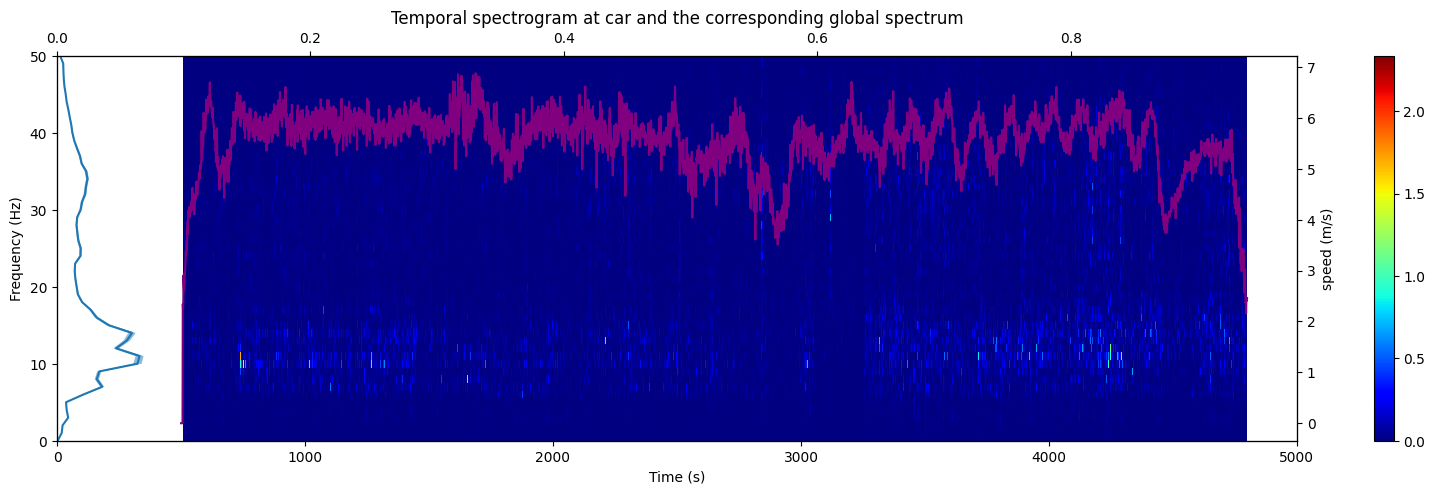

In [ ]:
fs_acc = 1/(np.round(np.mean(np.diff(acc_orig_df['seconds_elapsed'].values)), 2))
print(fs_acc)

spectrogram = get_spectrogram(acc_orig_df, fs=fs_acc, win_len=win_len, 
                            tv=loc_orig_df[['seconds_elapsed', 'speed']].values,
                            v_th_mask=v_th_mask)

global_spectrum_mean = np.nanmean(spectrogram[2], axis=1).reshape((-1, 1))
global_spectrum_std = np.nanstd(spectrogram[2], axis=1).reshape((-1, 1))
global_spectrum_sem = global_spectrum_std / np.sqrt(spectrogram[1].shape[0])
global_spectrum_l = global_spectrum_mean - 1.96*global_spectrum_sem
global_spectrum_u = global_spectrum_mean + 1.96*global_spectrum_sem

# 95% CI: +- 1.96 standar_error_mean
ax = plot_spectrogram(spectrogram, tlim=tlim, flim=flim, title='Temporal spectrogram at car and the corresponding global spectrum')
ax_twiny = ax.twiny()
ax_twiny.plot(global_spectrum_mean, spectrogram[0])
ax_twiny.fill_betweenx(spectrogram[0], global_spectrum_l.flatten(), global_spectrum_u.flatten(), alpha=0.5)
# ax_twiny.set_xscale('log')

xmax_ = max(global_spectrum_mean)*15
ax_twiny.set_xlim((0, xmax_[0]))

ax_twin = ax.twinx()
ax_twin.plot(loc_orig_df['seconds_elapsed'], loc_orig_df['speed'], color='purple', label='speed 1')
ax_twin.set_xlim(tlim)
ax_twin.set_ylabel('speed (m/s)')

plt.show()

Speed histogram

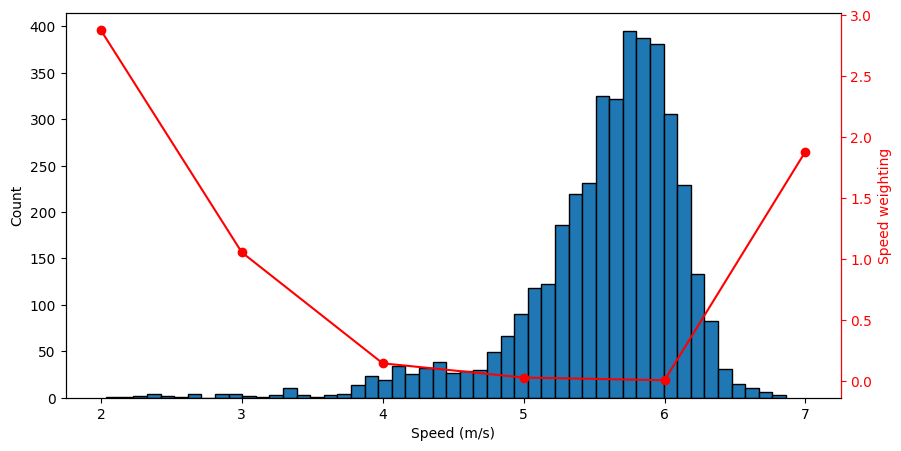

In [ ]:
mask = ~np.isnan(spectrogram[2]).any(axis=0)
speed_measure_all = np.interp(spectrogram[1][mask], loc_orig_df['seconds_elapsed'], loc_orig_df['speed'])

hist, bin_edges = np.histogram(speed_measure_all, bins=50)

# plot histogram from hist and bin_edges
plt.figure(figsize=(10, 5))
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), edgecolor='black', align='edge')
plt.xlabel('Speed (m/s)')
plt.ylabel('Count')


# speed weighting to compensate frequency bias
def speed_weighting(speed):
    """Returns a normalized weight for a given speed using hist, bin_edges, and interpolation.
    The weight is normalized so that the average of weights (for the provided speeds) is 1."""
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    hist_nonzero = np.where(hist == 0, 1, hist)  # avoid division by zero
    weights = 1 / hist_nonzero
    f = interpolate.interp1d(bin_centers, weights, bounds_error=False, fill_value="extrapolate")
    w = f(speed)
    # Normalize the weights so that their mean equals 1.
    return w / np.mean(w)

# test the function on a list of speed values
test_speeds = np.arange(int(np.nanmin(speed_measure_all)), int(np.nanmax(speed_measure_all)+1) + 1, 1)
test_weights = speed_weighting(test_speeds)
ax_twin2 = plt.twinx()
ax_twin2.set_ylabel('Speed weighting')
ax_twin2.plot(test_speeds, test_weights, marker='o', color='red', label='Speed weighting')
# color right axis and spine
ax_twin2.yaxis.label.set_color('red')
ax_twin2.tick_params(axis='y', colors='red')
ax_twin2.spines['right'].set_color('red')
plt.show()


In [ ]:
np.nanmax(speed_measure_all)

6.862389692328602

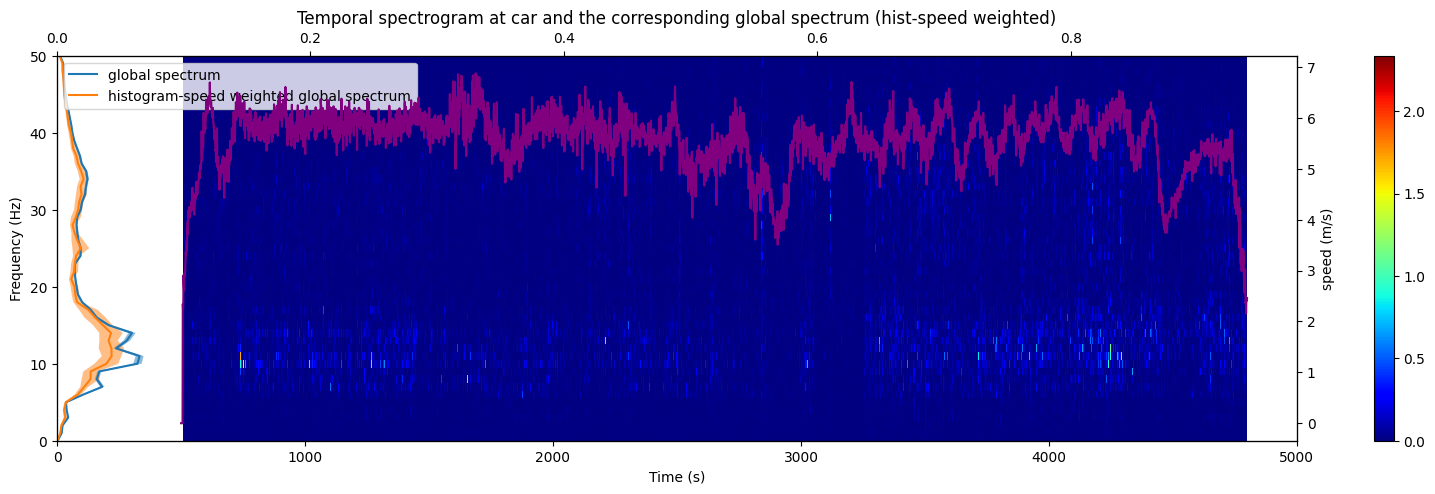

In [ ]:
speeds = np.interp(spectrogram[1], loc_orig_df['seconds_elapsed'], loc_orig_df['speed'])
Sxx = spectrogram[2]

mask = ~np.isnan(Sxx).any(axis=0)

global_spectrum_mean_weighted = np.nanmean(
    spectrogram[2][:, mask] * speed_weighting(speeds[mask]), 
    axis=1
    ).reshape((-1, 1))


global_spectrum_std_weighted = np.nanstd(spectrogram[2][:, mask] * speed_weighting(speeds[mask]), axis=1).reshape((-1, 1))
global_spectrum_sem_weighted = global_spectrum_std_weighted / np.sqrt(spectrogram[2][:, mask].shape[1])
global_spectrum_l_weighted = global_spectrum_mean_weighted - 1.96*global_spectrum_sem_weighted
global_spectrum_u_weighted = global_spectrum_mean_weighted + 1.96*global_spectrum_sem_weighted

# 95% CI: +- 1.96 standar_error_mean
ax = plot_spectrogram(spectrogram, tlim=tlim, flim=flim, title='Temporal spectrogram at car and the corresponding global spectrum (hist-speed weighted)')
ax_twiny = ax.twiny()
ax_twiny.plot(global_spectrum_mean, spectrogram[0], label='global spectrum')
ax_twiny.fill_betweenx(spectrogram[0], global_spectrum_l.flatten(), global_spectrum_u.flatten(), alpha=0.5)
ax_twiny.plot(global_spectrum_mean_weighted, spectrogram[0], label='histogram-speed weighted global spectrum')
ax_twiny.fill_betweenx(spectrogram[0], global_spectrum_l_weighted.flatten(), global_spectrum_u_weighted.flatten(), alpha=0.5)
ax_twiny.legend(loc='upper left')
# ax_twiny.set_xscale('log')

xmax_ = max((max(global_spectrum_mean), max(global_spectrum_mean_weighted)))*15
ax_twiny.set_xlim((0, xmax_[0]))

ax_twin = ax.twinx()
ax_twin.plot(loc_orig_df['seconds_elapsed'], loc_orig_df['speed'], color='purple', label='speed 1')
ax_twin.set_xlim(tlim)
ax_twin.set_ylabel('speed (m/s)')

plt.show()

# Approximate input (wheel acceleration at wheel-rail interface)

$$ |H(f)|^2 \approx S_{\mathrm{out, mean}}(f) = \frac{1}{N}\sum_{i=1}^{N}{S(f, t_i)}$$
$$ S_{\mathrm{in}}(f, t) \approx \frac{S_{\mathrm{out}}(f, t)}{S_{\mathrm{out, mean}}(f)} $$

$$S_{\mathrm{out, mean}}(f)$$


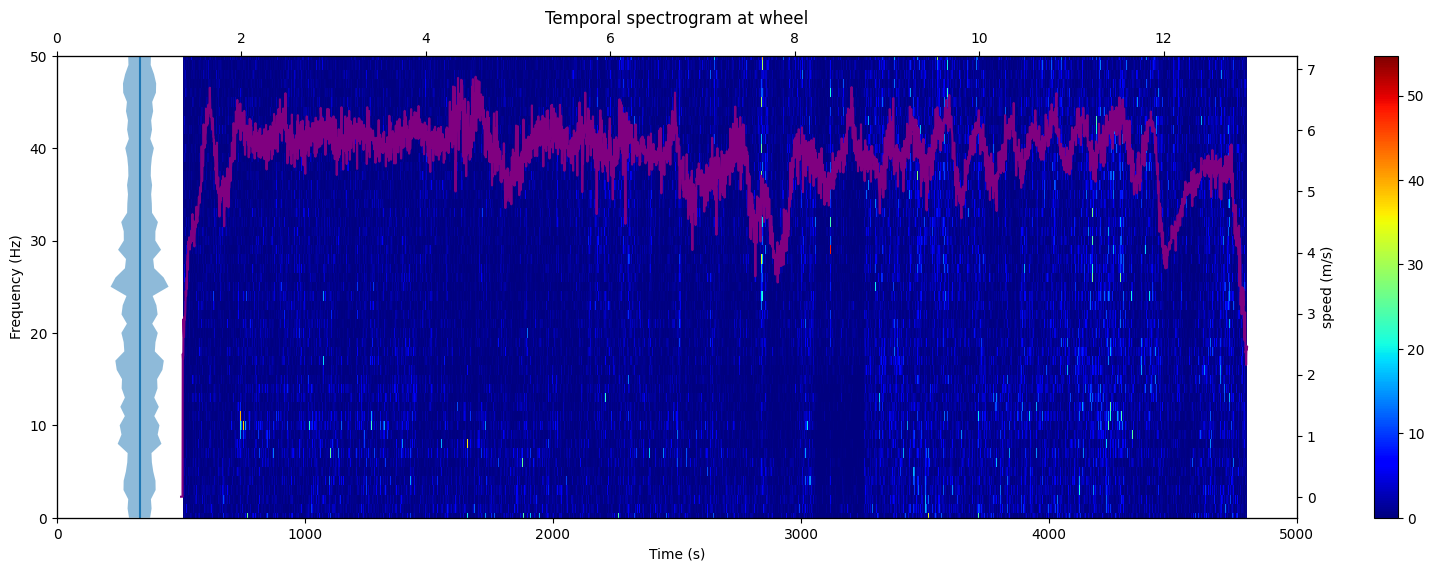

In [ ]:
spectrogram_in_mean = spectrogram[0], spectrogram[1], spectrogram[2]/global_spectrum_mean_weighted

global_spectrum_in_mean_weighted = np.nanmean(
    spectrogram_in_mean[2]  * speed_weighting(np.interp(spectrogram[1], loc_orig_df['seconds_elapsed'], loc_orig_df['speed'])), 
    axis=1).reshape((-1, 1))

global_spectrum_in_std_weighted = np.nanstd(spectrogram_in_mean[2]  * speed_weighting(np.interp(spectrogram[1], loc_orig_df['seconds_elapsed'], loc_orig_df['speed'])), axis=1).reshape((-1, 1))
global_spectrum_in_sem_weighted = global_spectrum_in_std_weighted / np.sqrt(spectrogram[1].shape[0])
global_spectrum_in_l_weighted = global_spectrum_in_mean_weighted - 1.96*global_spectrum_in_sem_weighted
global_spectrum_in_u_weighted = global_spectrum_in_mean_weighted + 1.96*global_spectrum_in_sem_weighted

fig, ax2 = plt.subplots(1,1, figsize=(20,6))

ax = plot_spectrogram(spectrogram_in_mean, tlim=tlim, flim=flim,
                      fig=fig, ax=ax2, title='Temporal spectrogram at wheel')

ax_twiny = ax.twiny()
ax_twiny.plot(global_spectrum_in_mean_weighted, spectrogram_in_mean[0])
ax_twiny.fill_betweenx(spectrogram[0], global_spectrum_in_l_weighted.flatten(), global_spectrum_in_u_weighted.flatten(), alpha=0.5)

xmax_ = max(global_spectrum_in_mean_weighted)*15
ax_twiny.set_xlim((0,xmax_[0]))

ax_twin = ax.twinx()
ax_twin.plot(loc_orig_df['seconds_elapsed'], loc_orig_df['speed'], color='purple', label='speed 1')
ax_twin.set_xlim(tlim)
ax_twin.set_ylabel('speed (m/s)')
plt.show()

# Approximate input (rail curvature at wheel-rail interface)

speed at $t$ is $v(t)$

horizontal position is $x(t)=\int_0^{t}v(\tau)\mathrm{d}t$

rail profile is $y(x)$

vertical position at $t$ is $y(x(t))=y(\int_0^{t}v(\tau)\mathrm{d}t)=\tilde{y}(t)$

vertical acceleration at $t$ is $\frac{\mathrm{d}^2 \tilde{y}}{\mathrm{d} t^2}(t)=\tilde{y}_{tt}(t)$

curvature at $x$ is $\frac{\mathrm{d}^2 y}{\mathrm{d} x^2}(x)=y_{xx}(x)$

$$
\tilde{y}_{tt}(t)
= \frac{\mathrm{d}}{\mathrm{d}t} \left( \frac{\mathrm{d} y(x(t))}{\mathrm{d}t} \right) 
= \frac{\mathrm{d}}{\mathrm{d}t} \left( \frac{\mathrm{d} y(x)}{\mathrm{d}x} \frac{\mathrm{d}x(t)}{\mathrm{d}t} \right)
$$

$$
\tilde{y}_{tt}(t)
= \frac{\mathrm{d}}{\mathrm{d}t} \big( y_x(x) \, v(t) \big) 
= v(t) \frac{\mathrm{d}}{\mathrm{d}t} \big( y_x(x(t)) \big) + \frac{\mathrm{d}v(t)}{\mathrm{d}t} y_x(x)
$$

$$
\tilde{y}_{tt}(t)
= v(t) \frac{\mathrm{d}}{\mathrm{d}t} \big( y_x \big( \int_0^{t}v(\tau)\mathrm{d}t \big) \big) + \frac{\mathrm{d}v(t)}{\mathrm{d}t} y_x(x)
$$

$$
\tilde{y}_{tt}(t)
= v(t) \big( \frac{\mathrm{d}}{\mathrm{d}x} y_x \frac{\mathrm{d}}{\mathrm{d}t} ( \int_0^{t}v(\tau)\mathrm{d}t ) \big) + \frac{\mathrm{d}v(t)}{\mathrm{d}t} y_x(x)
$$

$$
\tilde{y}_{tt}(t)
= v(t) \big( y_{xx} v(t) \big) + \frac{\mathrm{d}v(t)}{\mathrm{d}t} y_x(x)
$$

$$
\tilde{y}_{tt}(t)
= v(t)^2 y_{xx} + a(t) y_x(x)
$$

$$
\tilde{y}_{tt}(t) \approx v^2 \, y_{xx}(x)
$$

$$
\mathrm{\left[ \frac{m}{s^2} \right] = \left[ \frac{m^2}{s^2} \cdot \frac{1}{m} \right]}
$$

Fourier transforms

$\mathcal{F}_t[\tilde{y}_{tt}(t)] = \tilde{Y}_{tt}(f), \mathcal{F}_x[y_{xx}(x)] = Y_{xx}(f_s), f=v f_s$

Spectral Powers ($v$ is constant in each spectrum, but variable across them)

$S_\mathrm{in}(f, t) = v(t)^4 S_\mathrm{xx, in}(f_s, t)$

$$ S_\mathrm{xx, in}(f_s, t) = \frac{S_\mathrm{in}(v f_s, t)}{v(t)^4}$$

Spatial spectrogram $S_\mathrm{xx, in}(f_s, t)$

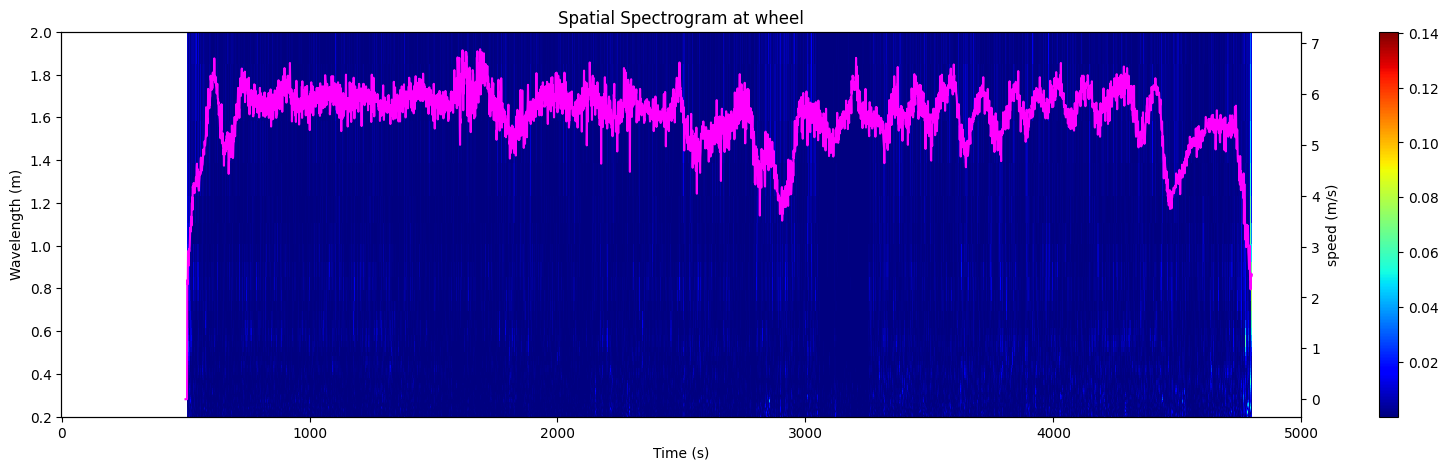

In [ ]:
min_wl = 0.2  # meter
max_wl = 2.0  # meter
wllim = (min_wl, max_wl)
fslim = (1/max_wl, 1/min_wl)

def get_spatial_spectrogram(spectrogram: tuple, tv: np.ndarray, min_wl: float, max_wl: float, v_th_mask: float = 0.0, exponent: float =  4.0) -> tuple:
    reg = 0
    spatial_frequencies = np.linspace(1/max_wl, 1/min_wl, len(spectrogram[0]))
    f, t, Sxx = spectrogram
    Sxx_spatial = 0 * Sxx
    for i, t_ in enumerate(t):
        v = np.interp(t_, tv[:, 0], tv[:, 1])
        f_ = v * spatial_frequencies
        S_ = np.interp(f_, f, Sxx[:, i], left=0, right=0) / ((v + reg) ** exponent)
        S_[f_ < 1 / win_len] = np.nan
        if v >= v_th_mask:
            Sxx_spatial[:, i] = S_
        else:
            Sxx_spatial[:, i] = np.nan
    return spatial_frequencies, t, Sxx_spatial

spatial_spectrogram_in = get_spatial_spectrogram(
    spectrogram_in_mean, loc_orig_df[['seconds_elapsed', 'speed']].values, 
    min_wl, max_wl,
    exponent=4, 
    v_th_mask=v_th_mask)

# Plots
# ax = plot_spectrogram(spatial_spectrogram_in, tlim=tlim, title='Spatial Spectrogram', spatial=True, flim=fslim)
ax = plot_spectrogram((1/spatial_spectrogram_in[0], spatial_spectrogram_in[1], spatial_spectrogram_in[2]), 
                      tlim=tlim, title='Spatial Spectrogram at wheel', spatial=True, period=True, flim=wllim)
ax_twin = ax.twinx()
ax_twin.plot(loc_orig_df['seconds_elapsed'], loc_orig_df['speed'], color='magenta', label='speed 1')
ax_twin.set_xlim(tlim)
ax_twin.set_ylabel('speed (m/s)')

plt.show()

{'inter_sleepers=0.57m': 0.57, 'wheel_base=1.73m': 1.73, 'inter_bogie=4.0m': 4.0, 'inter_sleepers/2': 0.285, 'wheel_base/2': 0.865, 'inter_bogie/2': 2.0, '1/(1/inter_sleepers - 2*(1/wheel_base))': 0.8500862068965516, '1/(1/inter_sleepers + 2*(1/wheel_base))': 0.4287391304347826, '1/(2*(1/inter_sleepers) - 2*(1/wheel_base))': 0.34121107266435985, '1/(2*(1/inter_sleepers) + 2*(1/wheel_base))': 0.2446898263027295}


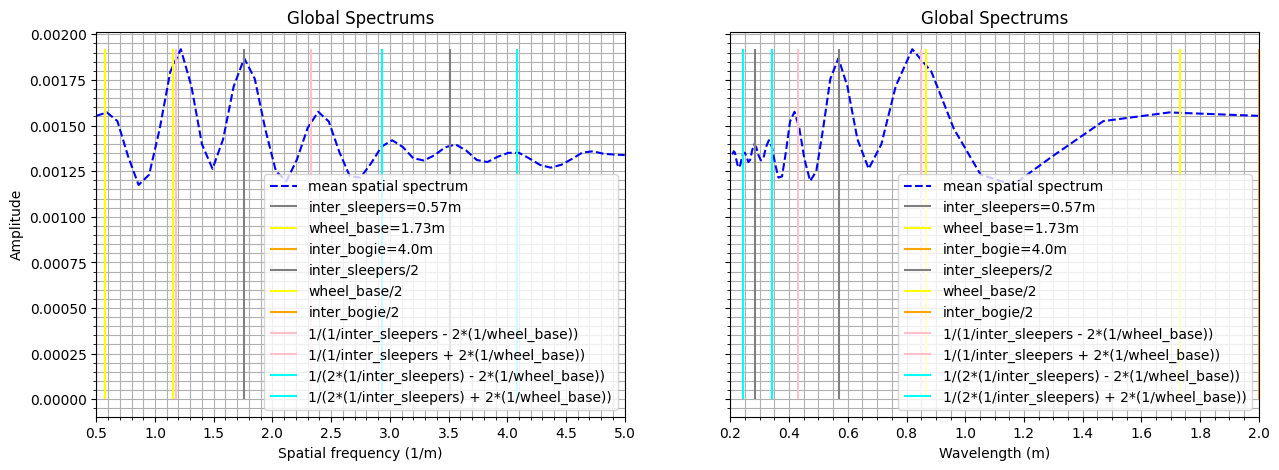

In [92]:

separations = {
    f'{inter_sleepers=}m': inter_sleepers,
    f'{wheel_base=}m': wheel_base,
    f'{inter_bogie=}m': inter_bogie,
    'inter_sleepers/2': inter_sleepers/2,
    'wheel_base/2': wheel_base/2,
    'inter_bogie/2': inter_bogie/2,
    '1/(1/inter_sleepers - 2*(1/wheel_base))': 1/(1/inter_sleepers - (1/wheel_base)),
    '1/(1/inter_sleepers + 2*(1/wheel_base))': 1/(1/inter_sleepers + (1/wheel_base)),
    '1/(2*(1/inter_sleepers) - 2*(1/wheel_base))': 1/(2/inter_sleepers - (1/wheel_base)),
    '1/(2*(1/inter_sleepers) + 2*(1/wheel_base))': 1/(2/inter_sleepers + (1/wheel_base)),
}

print(separations)

# ylim = .00000, .0015

colors = ['gray', 'yellow', 'orange', 'gray', 'yellow', 'orange', 'pink', 'pink', 'cyan', 'cyan']

# Global of FRF normalized - velocity normalized - spatial spectrum
f, t, Sxx = spatial_spectrogram_in

global_spatial_spectrum_mean = np.nanmean(
    Sxx  * speed_weighting(np.interp(spectrogram[1], loc_orig_df['seconds_elapsed'], loc_orig_df['speed'])), 
    axis=1
    )

global_spatial_spectrum_mean = np.nanmean(
    Sxx, 
    axis=1
    )

# global_spatial_spectrum_median = np.nanmedian(Sxx, axis=1)
# global_spatial_spectrum_mse = np.nanstd(Sxx, axis=1)/np.sqrt(len(t))
# global_spatial_spectrum_u = global_spatial_spectrum_mean +1.96*global_spatial_spectrum_mse
# global_spatial_spectrum_l = global_spatial_spectrum_mean -1.96*global_spatial_spectrum_mse


# Plot Global of FRF normalized - velocity normalized - spatial spectrum
fig, ax_two = plt.subplots(1, 2, figsize=(15, 5), sharey='row')
ax, ax_ = ax_two
# ax.set_yscale('log')
# ax.set_xscale('log')
ax.plot(f, global_spatial_spectrum_mean, label='mean spatial spectrum', color='blue', linestyle='--')
# ax.plot(f, global_spatial_spectrum_median, label='median spatial spectrum', color='blue')
# ax.fill_between(f, global_spatial_spectrum_l, global_spatial_spectrum_u, alpha=0.5)
ax.set_title('Global Spectrums')
ax.set_xlabel('Spatial frequency (1/m)')
ax.set_ylabel('Amplitude')
ax.set_xlim((1/wllim[1], 1/wllim[0]))
# ax.set_ylim(ylim)
ax.minorticks_on()
ax.grid(which='both')

for color, key in zip(colors, separations.keys()):
    ax.vlines(1/separations[key], 0, np.max(global_spatial_spectrum_mean), color=color, label=key)
    
ax.legend(loc='lower right')


# The same, but in terms of wavelength
wavelengths = 1 / f
# Plot Global of FRF normalized - velocity normalized - spatial spectrum in terms of wavelength
# fig, ax_ = plt.subplots(figsize=(10, 5))
# ax_.set_xscale('log')
ax_.plot(wavelengths, global_spatial_spectrum_mean, label='mean spatial spectrum', color='blue', linestyle='--')
# ax_.plot(wavelengths, global_spatial_spectrum_median, label='median spatial spectrum', color='blue')
# ax_.fill_between(wavelengths, global_spatial_spectrum_l, global_spatial_spectrum_u, alpha=0.5)
ax_.set_title('Global Spectrums')
ax_.set_xlabel('Wavelength (m)')
# ax_.set_ylabel('Amplitude')
# ax_.set_ylim(ylim)
ax_.set_xlim(wllim)
ax_.minorticks_on()

for color, key in zip(colors, separations.keys()):
    ax_.vlines(separations[key], 0, np.max(global_spatial_spectrum_mean), color=color, label=key)
  
ax_.grid(which='both')
ax_.legend()

plt.show()

## Rail state identification using harmonics

C:\Users\joses\AppData\Local\Temp\ipykernel_21812\1618017542.py:8: RuntimeWarning:

Mean of empty slice



Text(0, 0.5, 'Intensity (a.u.)')

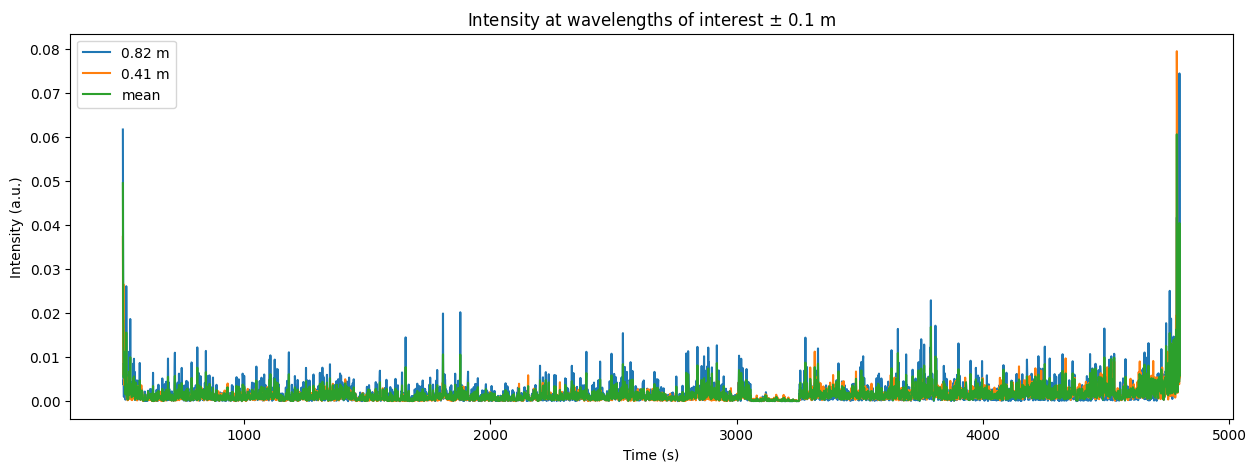

In [ ]:
wavelengths_of_interest = [inter_sleepers, inter_sleepers/2]
# wavelengths_of_interest = [inter_sleepers]
intensities_wl = []

delta_wl = 0.10  # adjust this value as needed
for wl_of_interest in wavelengths_of_interest:
    wl_mask = (wavelengths >= wl_of_interest - delta_wl) & (wavelengths <= wl_of_interest + delta_wl)
    intensity_wl = np.nanmean(spatial_spectrogram_in[2][wl_mask, :], axis=0)
    intensities_wl.append(intensity_wl)

intensity_wl_mean = np.mean(intensities_wl, axis=0)

# plot intensity at wavelength of interest
fig, ax = plt.subplots(figsize=(15, 5))
for wl_of_interest, intensity_wl in zip(wavelengths_of_interest, intensities_wl):
    ax.plot(spatial_spectrogram_in[1], intensity_wl, label=f'{wl_of_interest} m')

ax.plot(spatial_spectrogram_in[1], intensity_wl_mean, label='mean')

ax.legend()
ax.set_title(f'Intensity at wavelengths of interest $\pm$ {delta_wl} m')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Intensity (a.u.)')



In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go


# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Left y-axis: Intensity
fig.add_trace(
    go.Scatter(
        x=spatial_spectrogram_in[1],
        y=intensity_wl_mean,
        mode='lines',
        name=f'Intensity',
        line=dict(color='blue')
    ),
    secondary_y=False
)

# Right y-axis: Speed
fig.add_trace(
    go.Scatter(
        x=loc_orig_df['seconds_elapsed'], 
        y=loc_orig_df['speed'],
        mode='lines',
        name='Speed',
        line=dict(color='red')
    ),
    secondary_y=True
)

# Layout
fig.update_layout(
    title=f'Intensity and Speed at {wavelengths_of_interest} m',
    width=1000,
    height=400,
    legend=dict(x=0.01, y=0.99, borderwidth=0)
)

fig.update_xaxes(title_text="Time (s)")
fig.update_yaxes(title_text="Intensity (a.u.)", secondary_y=False)
fig.update_yaxes(title_text="Speed (m/s)", secondary_y=True)

fig.show()


# Paint intensity_wl in the map 

In [ ]:
# import cm
import branca.colormap as cm


loc_orig_df, acc_orig_df, map_output = load_dataset_n(source_path, dataset, t_ini, t_fin, 1)

# Create colormap from the intensity values
min_intensity = np.nanmin(intensity_wl_mean)
max_intensity = np.nanmax(intensity_wl_mean)
colormap = cm.LinearColormap(colors=['green', 'red'], vmin=min_intensity, vmax=max_intensity)

# For each time in the spatial spectrogram, compute the corresponding (lat, lon) from loc_orig_df
for t_val, intensity in zip(spatial_spectrogram_in[1], intensity_wl_mean):
    if np.isnan(intensity):
        continue
    # Find the nearest timestamp in loc_orig_df
    idx = (np.abs(loc_orig_df['seconds_elapsed'] - t_val)).idxmin()
    lat = loc_orig_df.loc[idx, 'latitude']
    lon = loc_orig_df.loc[idx, 'longitude']

    folium.CircleMarker(
        location=[float(lat), float(lon)],
        radius=50*intensity/np.nanmax(intensity_wl_mean),
        color=colormap(intensity),
        opacity=0.5,
        popup=f'Time: {t_val:.2f} s\nIntensity: {intensity:.2e} \n<a href="https://www.google.com/maps?q={lat:.7f},{lon:.7f}" target="_blank" rel="noopener noreferrer">GoogleMaps</a>'
    ).add_to(map_output)

# Add colormap legend to the map
colormap.caption = 'Intensity'
map_output.add_child(colormap)

display(map_output)

# create html and open in browser
map_output.save("intensity_map.html")



t_ini_acc=0.120134033203125, t_fin_acc=5130.579919921875; t_ini_loc=2.080814697265625, t_fin_loc=5130.0911127929685
t_ini_acc=500.0091015625, t_fin_acc=4799.989238769531; t_ini_loc=500.0826123046875, t_fin_loc=4799.09040625


# Predict accelerations from speeds and spatial_spectrogram_in

In [ ]:
speeds_of_interest = np.arange(1, 20 + 1, 2)

t = spatial_spectrogram_in[1]
f = spectrogram_in_mean[0]
fs = spatial_spectrogram_in[0]
Sxxs = spatial_spectrogram_in[2]
exponent = 4
spectrogram_in_for_speed = {}
for v in speeds_of_interest:
    for i, f_ in enumerate(f):
        fs_ = f_ / v  # [1/s] * [s/m] = [1/m]
        spectrogram_in_for_speed.update({
            v: (
                f, 
                t, 
                np.interp(fs_, fs, Sxxs[:, i] * (v ** exponent), left=0, right=0))
        })
    

In [ ]:
spectrogram_in_mean[0]

array([ 0.,  4.,  8., 12., 16., 20., 24., 28., 32., 36., 40., 44., 48.])